# vector fields and Helmholtz projection

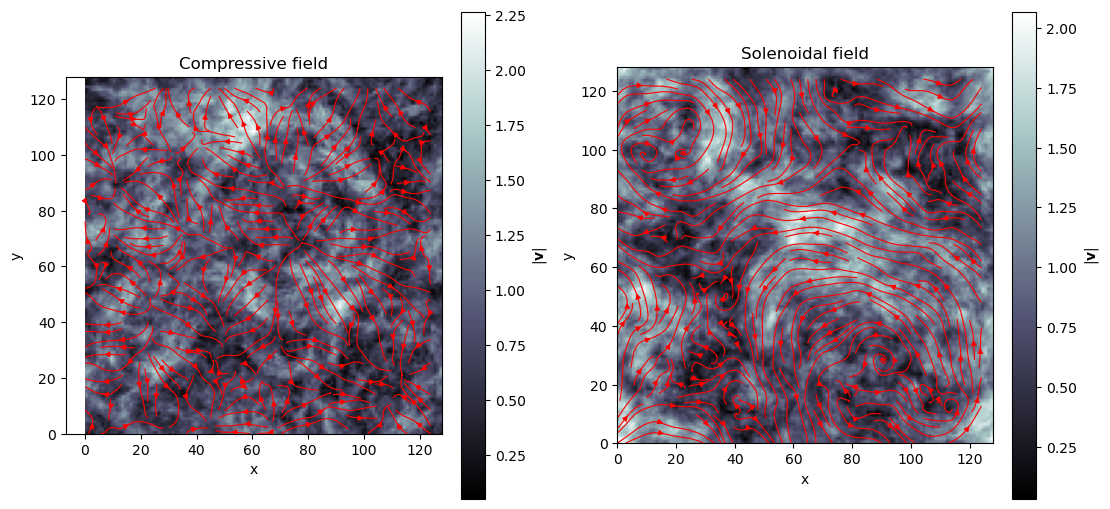

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def make_random_velocity_hat(N, spectral_index=11/3, seed=42):
    """
    Generate a random 3D vector field in Fourier space with
    P(k) ~ k^(-spectral_index).

    We start from real-space random fields and FFT them. This automatically
    guarantees Hermitian symmetry, so the inverse FFT gives real fields.
    """
    rng = np.random.default_rng(seed)

    vx = rng.normal(size=(N, N, N))
    vy = rng.normal(size=(N, N, N))
    vz = rng.normal(size=(N, N, N))

    vx_hat = np.fft.fftn(vx)
    vy_hat = np.fft.fftn(vy)
    vz_hat = np.fft.fftn(vz)

    kx = np.fft.fftfreq(N) * N
    ky = np.fft.fftfreq(N) * N
    kz = np.fft.fftfreq(N) * N

    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")
    K = np.sqrt(KX**2 + KY**2 + KZ**2)

    # amplitude scaling: |v_hat| ~ sqrt(P(k)) ~ k^(-p/2)
    amp = np.zeros_like(K)
    mask = K > 0
    amp[mask] = K[mask]**(-0.5 * spectral_index)

    vx_hat *= amp
    vy_hat *= amp
    vz_hat *= amp

    return vx_hat, vy_hat, vz_hat, KX, KY, KZ


def helmholtz_project(vx_hat, vy_hat, vz_hat, KX, KY, KZ):
    """
    Split Fourier-space velocity field into compressive and solenoidal parts.
    """
    K2 = KX**2 + KY**2 + KZ**2
    K = np.sqrt(K2)

    KHX = np.zeros_like(K)
    KHY = np.zeros_like(K)
    KHZ = np.zeros_like(K)

    mask = K > 0
    KHX[mask] = KX[mask] / K[mask]
    KHY[mask] = KY[mask] / K[mask]
    KHZ[mask] = KZ[mask] / K[mask]

    # compressive part: v_comp = (v . khat) khat
    vdotk = vx_hat * KHX + vy_hat * KHY + vz_hat * KHZ

    vx_hat_comp = vdotk * KHX
    vy_hat_comp = vdotk * KHY
    vz_hat_comp = vdotk * KHZ

    # solenoidal part: v_sol = v - v_comp
    vx_hat_sol = vx_hat - vx_hat_comp
    vy_hat_sol = vy_hat - vy_hat_comp
    vz_hat_sol = vz_hat - vz_hat_comp

    return (
        (vx_hat_comp, vy_hat_comp, vz_hat_comp),
        (vx_hat_sol, vy_hat_sol, vz_hat_sol),
    )


def ifft_vector(vhat):
    vx_hat, vy_hat, vz_hat = vhat

    vx = np.real(np.fft.ifftn(vx_hat))
    vy = np.real(np.fft.ifftn(vy_hat))
    vz = np.real(np.fft.ifftn(vz_hat))

    return vx, vy, vz


def normalize_vector(v):
    vx, vy, vz = v
    vrms = np.sqrt(np.mean(vx**2 + vy**2 + vz**2))
    return vx / vrms, vy / vrms, vz / vrms


def plot_velocity_slice(v_comp, v_sol, zslice=None, step=4):
    vx_c, vy_c, vz_c = v_comp
    vx_s, vy_s, vz_s = v_sol

    N = vx_c.shape[0]

    if zslice is None:
        zslice = N // 2

    x = np.arange(N)
    y = np.arange(N)
    X, Y = np.meshgrid(x, y, indexing="ij")

    speed_c = np.sqrt(
        vx_c[:, :, zslice]**2
        + vy_c[:, :, zslice]**2
        + vz_c[:, :, zslice]**2
    )

    speed_s = np.sqrt(
        vx_s[:, :, zslice]**2
        + vy_s[:, :, zslice]**2
        + vz_s[:, :, zslice]**2
    )

    fig, axs = plt.subplots(
        ncols=2,
        figsize=(11, 5),
        constrained_layout=True,
    )

    im0 = axs[0].imshow(
        speed_c.T,
        origin="lower",
        extent=[0, N, 0, N],
        cmap="bone"
    )
    axs[0].streamplot(
        X[::step, ::step].T,
        Y[::step, ::step].T,
        vx_c[::step, ::step, zslice].T,
        vy_c[::step, ::step, zslice].T,
        density=1.5,
        linewidth=0.8,
        arrowsize=0.8,
        color="red"
    )
    axs[0].set_title("Compressive field")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("y")
    fig.colorbar(im0, ax=axs[0], label=r"$|\mathbf{v}|$")

    im1 = axs[1].imshow(
        speed_s.T,
        origin="lower",
        extent=[0, N, 0, N],
        cmap="bone"
    )
    axs[1].streamplot(
        X[::step, ::step].T,
        Y[::step, ::step].T,
        vx_s[::step, ::step, zslice].T,
        vy_s[::step, ::step, zslice].T,
        density=1.5,
        linewidth=0.8,
        arrowsize=0.8,
        color="red"
    )
    axs[1].set_title("Solenoidal field")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("y")
    fig.colorbar(im1, ax=axs[1], label=r"$|\mathbf{v}|$")

    plt.show()


# ------------------------------------------------------------
# Example
# ------------------------------------------------------------

N = 128
spectral_index = 11 / 3

vx_hat, vy_hat, vz_hat, KX, KY, KZ = make_random_velocity_hat(
    N,
    spectral_index=spectral_index,
    seed=123,
)

vhat_comp, vhat_sol = helmholtz_project(
    vx_hat, vy_hat, vz_hat,
    KX, KY, KZ,
)

v_comp = normalize_vector(ifft_vector(vhat_comp))
v_sol = normalize_vector(ifft_vector(vhat_sol))

plot_velocity_slice(
    v_comp,
    v_sol,
    zslice=N // 2,
    step=4,
)